# Geometric perturbation and latent-magnitude correlation

This notebook reads the table written by `scripts/run_geometric_registration_experiment.py`. It does not rerun diffusion.

## Pipeline

For each sample the experiment draws one Gaussian latent, generates one image, and reuses that image for every condition:

```text
z → diffusion → image x → geometric transform → DDIM inversion → z_hat
```

The score is the Pearson correlation of the unsigned magnitudes, `pearsonr(|z|, |z_hat|)`. Signed correlation, percentile distance, and watermark decoding are not part of this comparison.

Conditions are a no-transform baseline, horizontal translations of 1, 2, 5, and 10 pixels, the same four vertical translations, and rotations of 1°, 2°, 5°, and 10°. New pixels are filled with black. Translations are exact nearest-neighbor shifts (content moves right or down). Rotations are bicubic, counterclockwise about the center, and stay at the model resolution.

The question is empirical: does this correlation fall as the geometric perturbation grows, and is the drop large enough to be useful as an alignment signal? The plots below describe the saved run. They do not assume that it falls.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

RUN_DIR = Path("results/geometric_registration/run_001")
csv_path = RUN_DIR / "correlations.csv"
if not csv_path.is_file():
    raise SystemExit(f"missing {csv_path}. Copy the HiPerGator run directory here first.")

raw = pd.read_csv(csv_path)
meta = json.loads((RUN_DIR / "metadata.json").read_text(encoding="utf-8"))
need = {"sample_id", "transformation_type", "magnitude", "correlation"}
missing = need - set(raw.columns)
if missing:
    raise SystemExit(f"correlations.csv is missing columns: {sorted(missing)}")

order = ["baseline", "horizontal_translation", "vertical_translation", "rotation"]
raw["transformation_type"] = pd.Categorical(raw.transformation_type, categories=order, ordered=True)
print(f"samples {raw.sample_id.nunique()}, rows {len(raw)}, seed {meta.get('seed')}, model {meta.get('model_id')}")
print(f"resolution {meta.get('image_size')}, latent shape {meta.get('latent_shape')}")
print("padding:", meta.get("padding"))

samples 100, rows 1300, seed 42, model runwayml/stable-diffusion-v1-5
resolution 512, latent shape [1, 4, 64, 64]
padding: constant black RGB (0, 0, 0)


## Summary

Mean, standard deviation, and median of the magnitude correlation across samples. The baseline row is the untransformed image.

In [2]:
summary = (
    raw.groupby(["transformation_type", "magnitude"], observed=True)["correlation"]
    .agg(mean="mean", std="std", median="median", n="count")
    .reset_index()
)
display(summary.round(4))

,transformation_type,magnitude,mean,std,median,n
0,baseline,0.0,0.7713,0.0522,0.7758,100
1,horizontal_translation,1.0,0.6851,0.0518,0.6912,100
2,horizontal_translation,2.0,0.4736,0.0465,0.4784,100
3,horizontal_translation,5.0,0.0560,0.0110,0.0553,100
4,horizontal_translation,10.0,-0.0001,0.0085,0.0000,100
5,vertical_translation,1.0,0.6675,0.0505,0.6672,100
6,vertical_translation,2.0,0.4068,0.0430,0.4088,100
7,vertical_translation,5.0,0.0392,0.0115,0.0384,100
8,vertical_translation,10.0,-0.0007,0.0081,-0.0008,100
9,rotation,1.0,0.2061,0.0239,0.2070,100


## Correlation versus perturbation magnitude

Error bars are ±1 standard error of the mean. The baseline mean is drawn as a horizontal line on each panel.

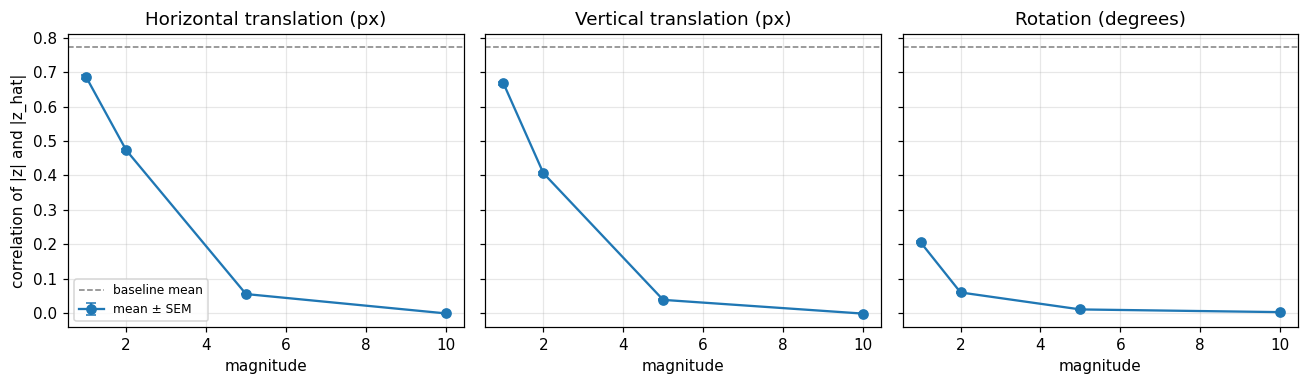

In [3]:
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
baseline_mean = float(summary.loc[summary.transformation_type == "baseline", "mean"].iloc[0])
panels = [
    ("horizontal_translation", "Horizontal translation (px)"),
    ("vertical_translation", "Vertical translation (px)"),
    ("rotation", "Rotation (degrees)"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, (kind, title) in zip(axes, panels):
    sub = summary[summary.transformation_type == kind].sort_values("magnitude")
    sem = sub["std"] / np.sqrt(sub["n"])
    ax.errorbar(sub.magnitude, sub["mean"], yerr=sem, fmt="o-", capsize=3, label="mean ± SEM")
    ax.axhline(baseline_mean, color="gray", ls="--", lw=1, label="baseline mean")
    ax.set(xlabel="magnitude", title=title)
axes[0].set_ylabel("correlation of |z| and |z_hat|")
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(RUN_DIR / "correlation_vs_magnitude.png", bbox_inches="tight")
plt.show()

## Distribution across samples

Each violin is one condition. The baseline is included so the shifted and rotated images can be compared with the unperturbed inversion of the same pictures.

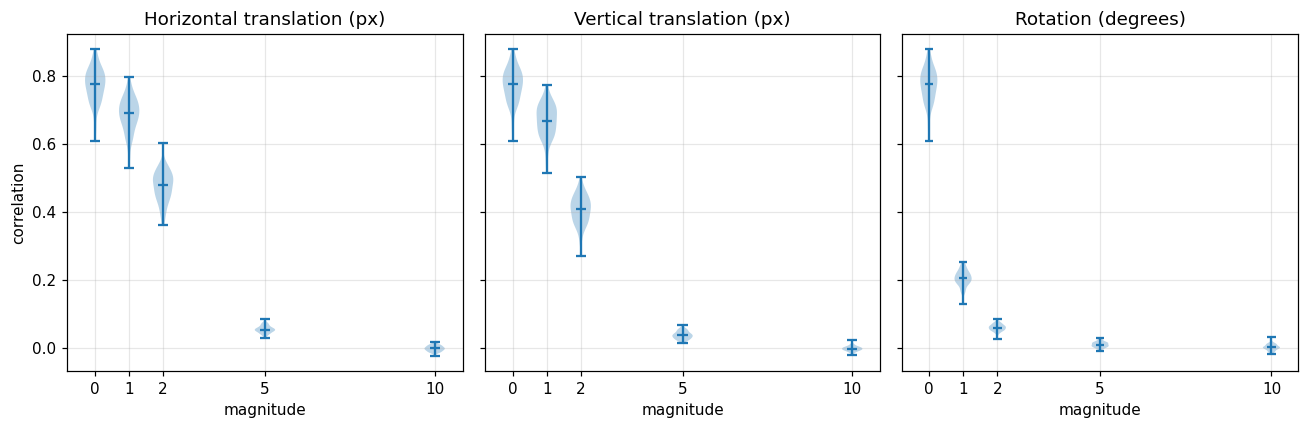

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.0), sharey=True)
for ax, (kind, title) in zip(axes, panels):
    block = raw[raw.transformation_type.isin(["baseline", kind])]
    magnitudes = sorted(block.magnitude.unique())
    groups = [block.loc[block.magnitude == m, "correlation"].to_numpy() for m in magnitudes]
    ax.violinplot(groups, positions=magnitudes, widths=0.6 if kind != "rotation" else 0.5, showmedians=True)
    ax.set(xlabel="magnitude", title=title, xticks=magnitudes)
axes[0].set_ylabel("correlation")
fig.tight_layout()
fig.savefig(RUN_DIR / "correlation_violins.png", bbox_inches="tight")
plt.show()

## Matched comparison with the baseline

For each sample, `delta = correlation(condition) − correlation(baseline)`. A negative delta means that condition correlates less than the untransformed inversion of the same image.

,transformation_type,magnitude,mean,std,median,n
0,horizontal_translation,1.0,-0.0862,0.0104,-0.0859,100
1,horizontal_translation,2.0,-0.2978,0.0262,-0.3004,100
2,horizontal_translation,5.0,-0.7153,0.0499,-0.7194,100
3,horizontal_translation,10.0,-0.7714,0.0528,-0.7792,100
4,vertical_translation,1.0,-0.1039,0.0130,-0.1042,100
5,vertical_translation,2.0,-0.3645,0.0328,-0.3663,100
6,vertical_translation,5.0,-0.7321,0.0526,-0.7360,100
7,vertical_translation,10.0,-0.7720,0.0525,-0.7730,100
8,rotation,1.0,-0.5652,0.0438,-0.5697,100
9,rotation,2.0,-0.7106,0.0488,-0.7144,100


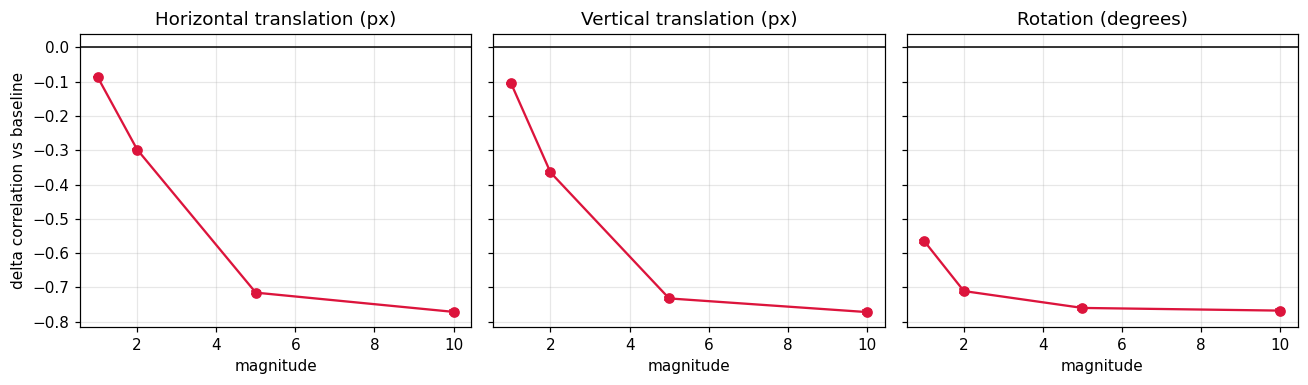

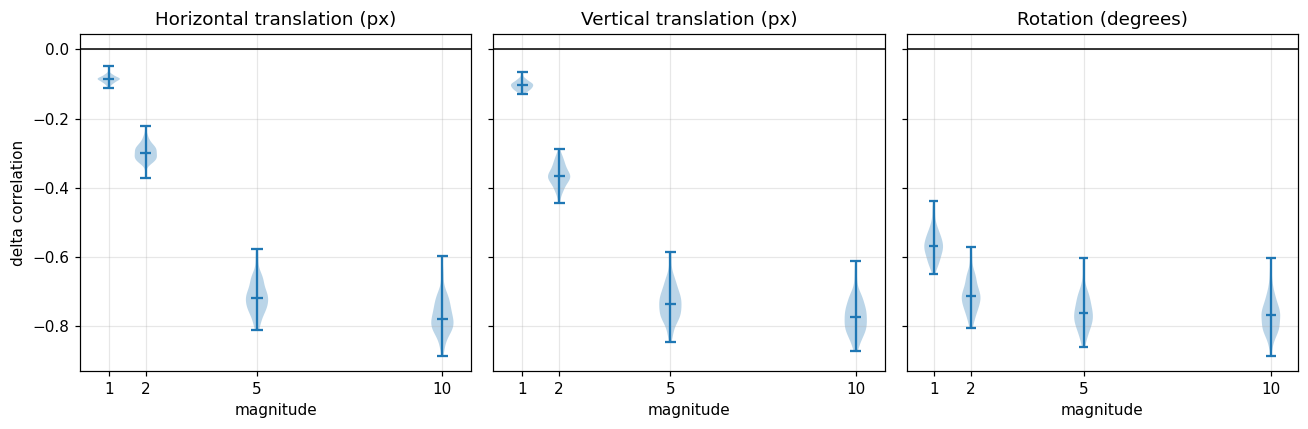

In [5]:
base = raw.loc[raw.transformation_type == "baseline", ["sample_id", "correlation"]].rename(
    columns={"correlation": "baseline"}
)
matched = raw.merge(base, on="sample_id", how="inner")
matched = matched[matched.transformation_type != "baseline"].copy()
matched["delta"] = matched.correlation - matched.baseline

delta_summary = (
    matched.groupby(["transformation_type", "magnitude"], observed=True)["delta"]
    .agg(mean="mean", std="std", median="median", n="count")
    .reset_index()
)
display(delta_summary.round(4))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, (kind, title) in zip(axes, panels):
    sub = delta_summary[delta_summary.transformation_type == kind].sort_values("magnitude")
    sem = sub["std"] / np.sqrt(sub["n"])
    ax.errorbar(sub.magnitude, sub["mean"], yerr=sem, fmt="o-", capsize=3, color="crimson")
    ax.axhline(0, color="k", lw=1)
    ax.set(xlabel="magnitude", title=title)
axes[0].set_ylabel("delta correlation vs baseline")
fig.tight_layout()
fig.savefig(RUN_DIR / "delta_vs_magnitude.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4.0), sharey=True)
for ax, (kind, title) in zip(axes, panels):
    block = matched[matched.transformation_type == kind]
    magnitudes = sorted(block.magnitude.unique())
    groups = [block.loc[block.magnitude == m, "delta"].to_numpy() for m in magnitudes]
    ax.violinplot(groups, positions=magnitudes, widths=0.6 if kind != "rotation" else 0.5, showmedians=True)
    ax.axhline(0, color="k", lw=1)
    ax.set(xlabel="magnitude", title=title, xticks=magnitudes)
axes[0].set_ylabel("delta correlation")
fig.tight_layout()
fig.savefig(RUN_DIR / "delta_violins.png", bbox_inches="tight")
plt.show()

## Example transformations

These are the sample-0 images saved by the experiment: the original generation, a 5 px horizontal shift, a 5 px vertical shift, and a 5° rotation. Black pixels are the fill introduced by the transform.

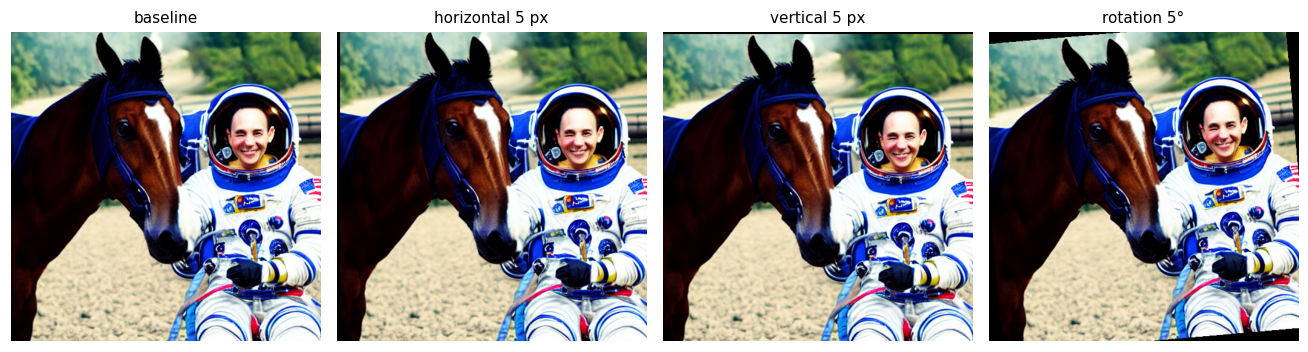

In [6]:
examples = [
    ("baseline", RUN_DIR / "examples" / "sample000_baseline.png"),
    ("horizontal 5 px", RUN_DIR / "examples" / "sample000_horizontal_translation_5.png"),
    ("vertical 5 px", RUN_DIR / "examples" / "sample000_vertical_translation_5.png"),
    ("rotation 5°", RUN_DIR / "examples" / "sample000_rotation_5.png"),
]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, (title, path) in zip(axes, examples):
    ax.axis("off")
    ax.set_title(title, fontsize=10)
    if path.is_file():
        ax.imshow(plt.imread(path))
    else:
        ax.text(0.5, 0.5, "not saved", ha="center", va="center")
fig.tight_layout()
plt.show()

## What this run shows

The cell below only describes the table that was loaded. A decrease on these samples would mean the unsigned-magnitude correlation moved with the perturbation in this experiment. It would not, by itself, establish that the correlation is a reliable registration signal under other models, prompts, or inversions.

In [7]:
print(f"baseline mean correlation: {baseline_mean:.4f}")
for kind, title in panels:
    sub = summary[summary.transformation_type == kind].sort_values("magnitude")
    means = sub["mean"].to_numpy()
    steps = np.diff(means)
    direction = "non-increasing" if np.all(steps <= 1e-12) else "not monotone"
    deltas = delta_summary[delta_summary.transformation_type == kind].sort_values("magnitude")
    print(f"{title}: mean correlation by magnitude is {direction}")
    print("  magnitudes", sub.magnitude.round(3).tolist())
    print("  means     ", [round(float(v), 4) for v in means])
    print("  mean delta", [round(float(v), 4) for v in deltas["mean"]])

baseline mean correlation: 0.7713
Horizontal translation (px): mean correlation by magnitude is non-increasing
  magnitudes [1.0, 2.0, 5.0, 10.0]
  means      [0.6851, 0.4736, 0.056, -0.0001]
  mean delta [-0.0862, -0.2978, -0.7153, -0.7714]
Vertical translation (px): mean correlation by magnitude is non-increasing
  magnitudes [1.0, 2.0, 5.0, 10.0]
  means      [0.6675, 0.4068, 0.0392, -0.0007]
  mean delta [-0.1039, -0.3645, -0.7321, -0.772]
Rotation (degrees): mean correlation by magnitude is non-increasing
  magnitudes [1.0, 2.0, 5.0, 10.0]
  means      [0.2061, 0.0607, 0.0114, 0.0036]
  mean delta [-0.5652, -0.7106, -0.7599, -0.7677]
